In [85]:
import numpy as np
from Likelihoods import *
from LLMs_routines import *
from aggregation_process_CES import *
import torch
from openai import OpenAI
from agents import Agent, Runner

In [75]:
CONTEXT_PROMPT = (
    "You are one of two collaborating assessors trying to determine the true "
    "state among three possibilities: A, B, C. Each of you receives your own "
    "private stream of signals. Your own signals are informative enough to "
    "rule out one of the two false states, but not the other: there is "
    "exactly one false state that your own signals cannot distinguish from "
    "the truth, because your signal likelihoods are identical for the true "
    "state and that particular false state. Your partner has a different "
    "blind spot: there is a different false state that your partner cannot "
    "distinguish from the truth using their own signals, but that you CAN "
    "distinguish. Because your blind spots do not overlap, neither of you "
    "can identify the true state alone, but by combining your assessments, "
    "together you can identify it correctly.\n\n"
)


Compare LLM aggregation with the arithmetic and geometric rules.

In [22]:
import numpy as np
rng = np.random.default_rng(0)

def valid_belief(rng, lo=0.05, hi=0.75, conc=4.0):
    """Draw from the simplex, resample if any component is too extreme."""
    while True:
        mu = rng.dirichlet(np.full(K, conc))
        if mu.min() >= lo and mu.max() <= hi:
            return mu

for _ in range(5):
    mu_i = valid_belief(rng)
    mu_j = valid_belief(rng)

    z = llm_update_without_bayes(mu_i, mu_j, LABELS)
    arith = 0.5*mu_i + 0.5*mu_j
    geo = np.sqrt(mu_i*mu_j); geo /= geo.sum()

    print("mu_i:", np.round(mu_i, 3), " mu_j:", np.round(mu_j, 3))
    print("  LLM: ", np.round(z, 3), "  arithmetic:", np.round(arith, 3),
          "  geometric:", np.round(geo, 3))

mu_i: [0.335 0.431 0.234]  mu_j: [0.572 0.209 0.219]
  LLM:  [0.453 0.32  0.227]   arithmetic: [0.453 0.32  0.227]   geometric: [0.454 0.311 0.235]
mu_i: [0.147 0.335 0.518]  mu_j: [0.431 0.327 0.242]
  LLM:  [0.289 0.331 0.38 ]   arithmetic: [0.289 0.331 0.38 ]   geometric: [0.269 0.353 0.378]
mu_i: [0.519 0.221 0.261]  mu_j: [0.216 0.354 0.43 ]
  LLM:  [0.38  0.287 0.333]   arithmetic: [0.367 0.287 0.345]   geometric: [0.352 0.295 0.353]
mu_i: [0.264 0.556 0.18 ]  mu_j: [0.376 0.229 0.395]
  LLM:  [0.32  0.393 0.287]   arithmetic: [0.32  0.393 0.287]   geometric: [0.336 0.38  0.284]
mu_i: [0.508 0.269 0.224]  mu_j: [0.211 0.562 0.227]
  LLM:  [0.36  0.415 0.225]   arithmetic: [0.36  0.415 0.225]   geometric: [0.348 0.413 0.239]


In [44]:
import importlib
import LLMs_routines
importlib.reload(LLMs_routines)
from LLMs_routines import *


z_agg = llm_update_without_bayes(mu1, mu2, LABELS)
z_combined = llm_update_with_signal(mu1, mu2, "A", LABELS, Lx)

lik = np.array([Lx[k][0] for k in STATES])
correct_post = z_agg * lik
correct_post /= correct_post.sum()

print("aggregation only:      ", np.round(z_agg, 3))
print("correct after signal A:", np.round(correct_post, 3))
print("LLM combined output:   ", np.round(z_combined, 3))
print("error on state C:      ", round(z_combined[2] - correct_post[2], 3))

aggregation only:       [0.345 0.31  0.345]
correct after signal A: [0.477 0.428 0.095]
LLM combined output:    [0.476 0.429 0.095]
error on state C:       -0.0


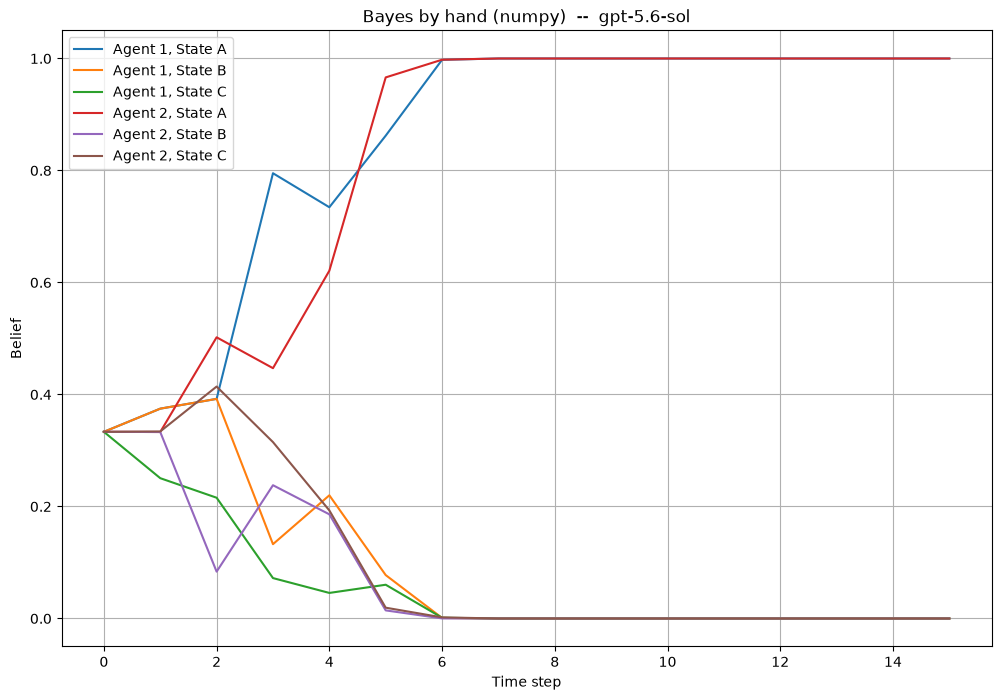

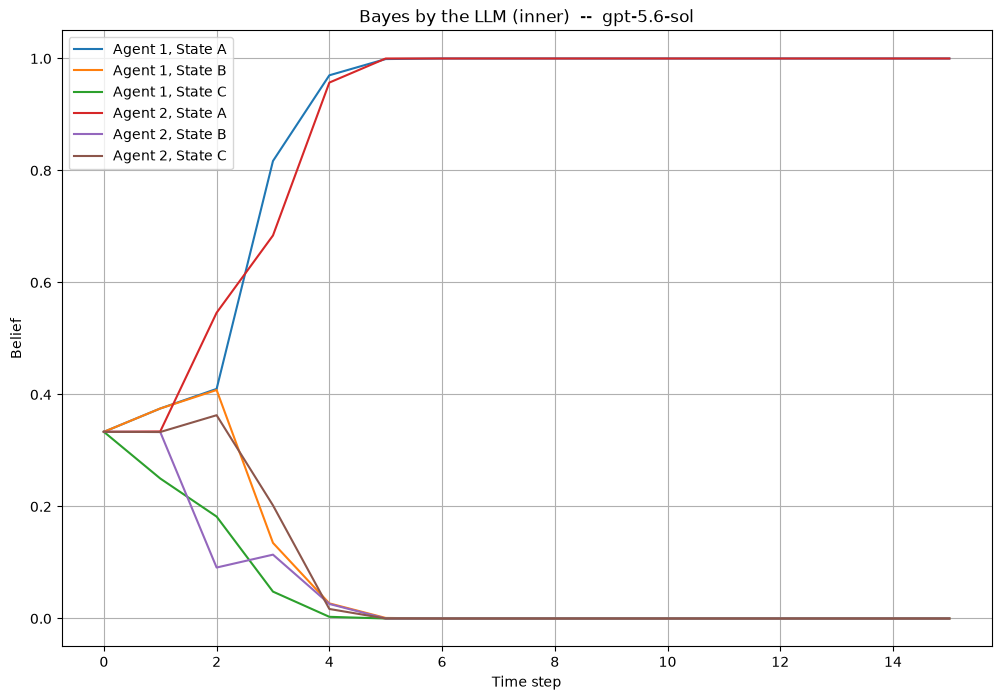

In [45]:
N_run = 15
Belief_init_1 = np.ones(K) / K
Belief_init_2 = np.ones(K) / K

np.random.seed(0)
Dynamics_hand = Dynamics_with_by_hand_bayes(Belief_init_1, Belief_init_2, Lx, Ly, N_run)

np.random.seed(0)
Dynamics_llm  = Dynamics_with_signal(Belief_init_1, Belief_init_2, Lx, Ly, N_run)

plot_Dynamic(Dynamics_hand, title=f"Bayes by hand (numpy)  --  {MODEL_NAME}")
plot_Dynamic(Dynamics_llm,  title=f"Bayes by the LLM (inner)  --  {MODEL_NAME}")

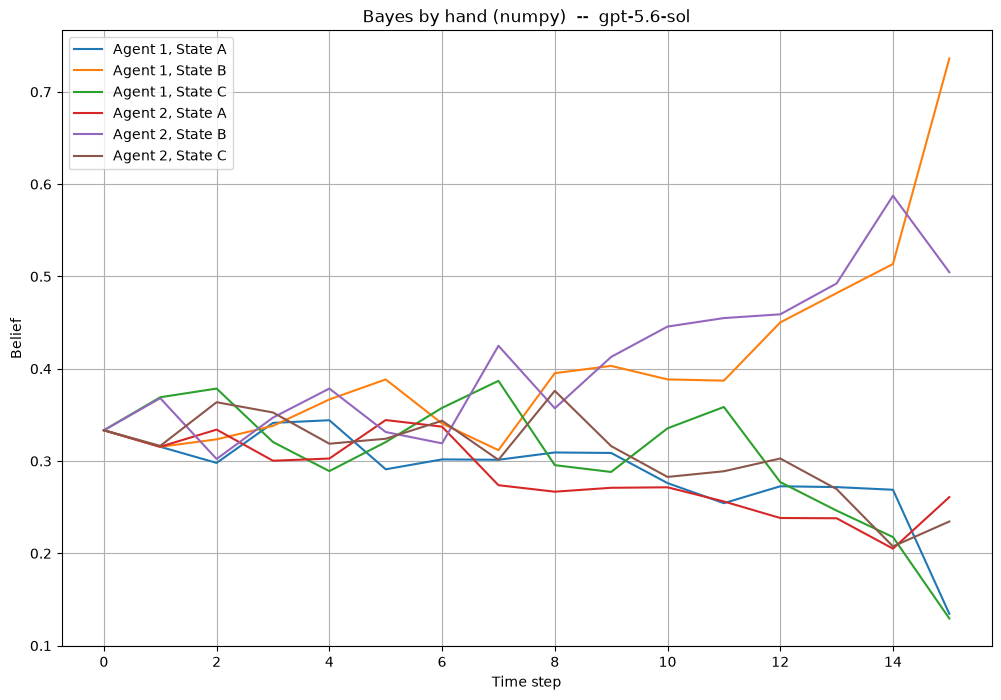

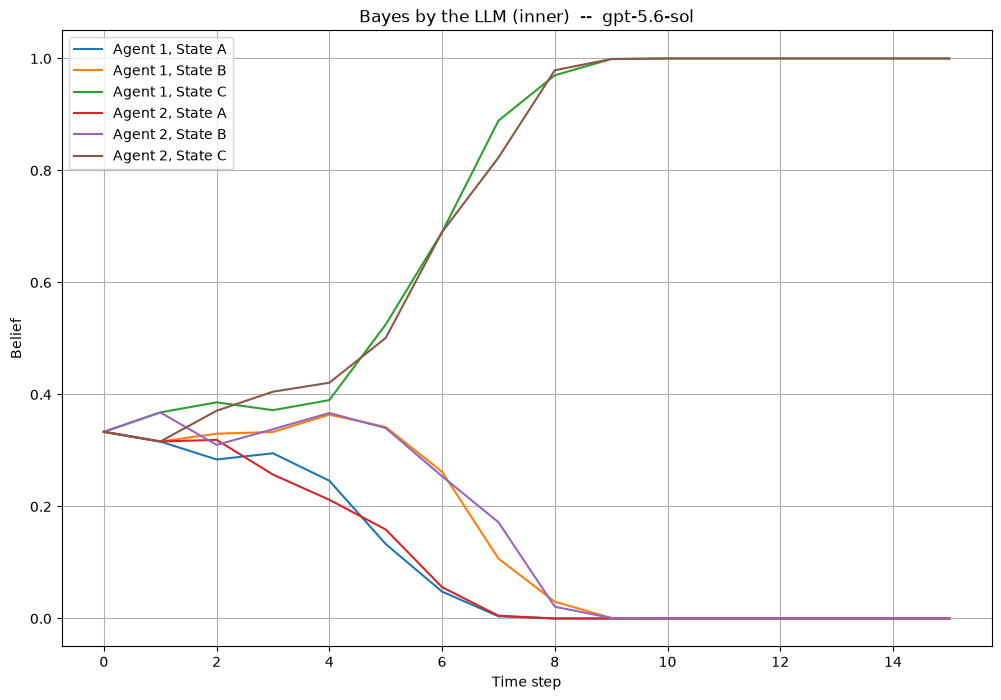

In [47]:
N_run = 15
Belief_init_1 = np.ones(K) / K
Belief_init_2 = np.ones(K) / K

np.random.seed(0)
Dynamics_hand = Dynamics_with_by_hand_bayes(Belief_init_1, Belief_init_2, Lx_close, Ly_close, N_run)

np.random.seed(0)
Dynamics_llm  = Dynamics_with_signal(Belief_init_1, Belief_init_2, Lx_close, Ly_close, N_run)

plot_Dynamic(Dynamics_hand, title=f"Bayes by hand (numpy)  --  {MODEL_NAME}")
plot_Dynamic(Dynamics_llm,  title=f"Bayes by the LLM (inner)  --  {MODEL_NAME}")

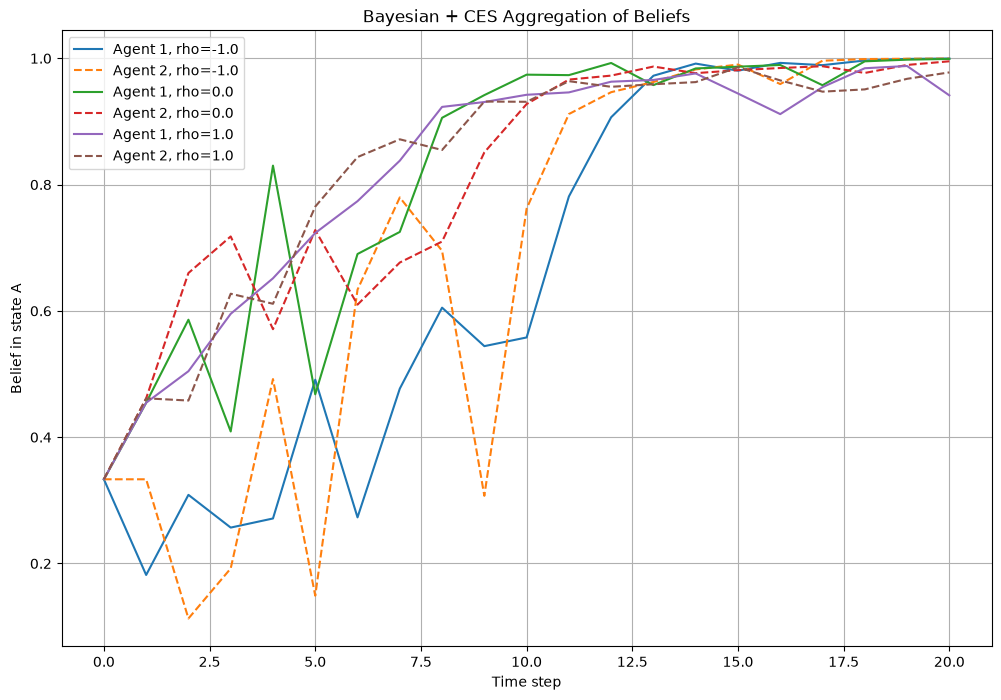

In [69]:
import importlib
import aggregation_process_CES
importlib.reload(aggregation_process_CES)
from aggregation_process_CES import *
beliefs_init = np.array([
    np.ones(K) / K,   # agent 1's initial belief
    np.ones(K) / K,   # agent 2's initial belief
])

plot_bayes_plus_CES_aggregate(20, Lx, Ly, [-1.0, 0.0, 1.0], beliefs_init)

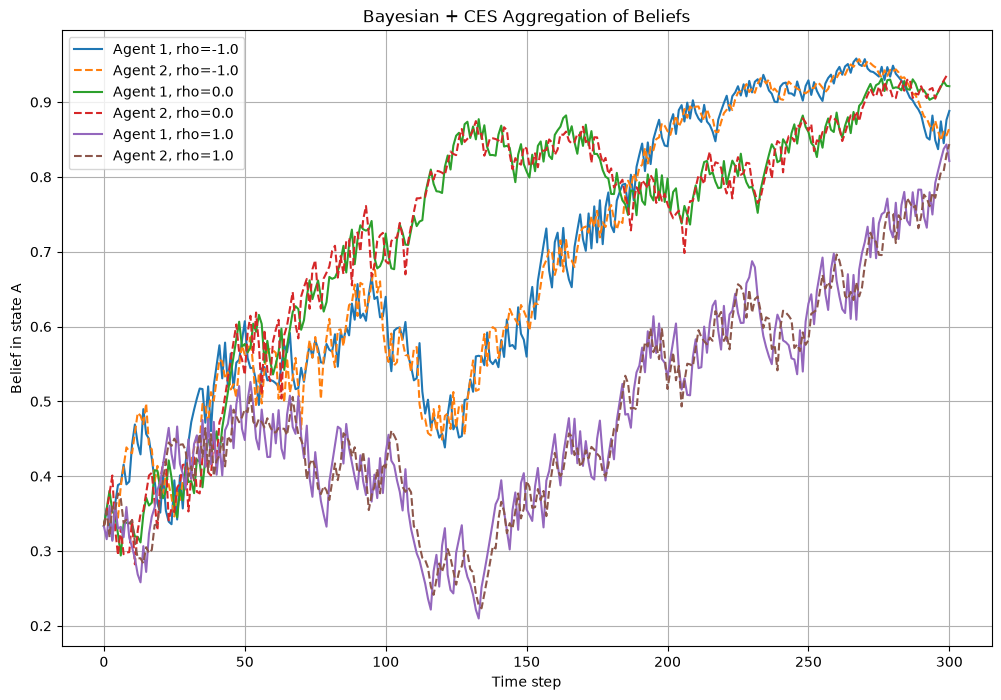

In [72]:
beliefs_init = np.array([
    np.ones(K) / K,   # agent 1's initial belief
    np.ones(K) / K,   # agent 2's initial belief
])

plot_bayes_plus_CES_aggregate(300, Lx_close, Ly_close, [-1.0, 0.0, 1.0], beliefs_init)

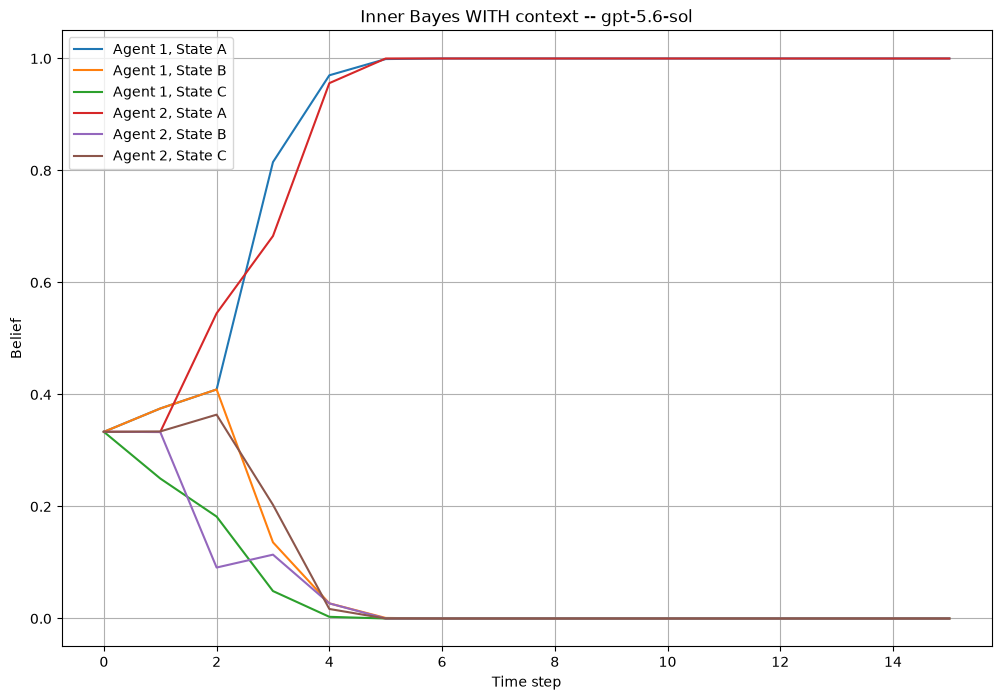

In [ ]:
N_run = 15
Belief_init_1 = np.ones(K) / K
Belief_init_2 = np.ones(K) / K


Dyn_ctx = Dynamics_with_signal(
    Belief_init_1, Belief_init_2, Lx, Ly, N_run=15,
    context_prompt=CONTEXT_PROMPT)

plot_Dynamic(Dyn_ctx, title=f"Inner Bayes WITH context -- {MODEL_NAME}")

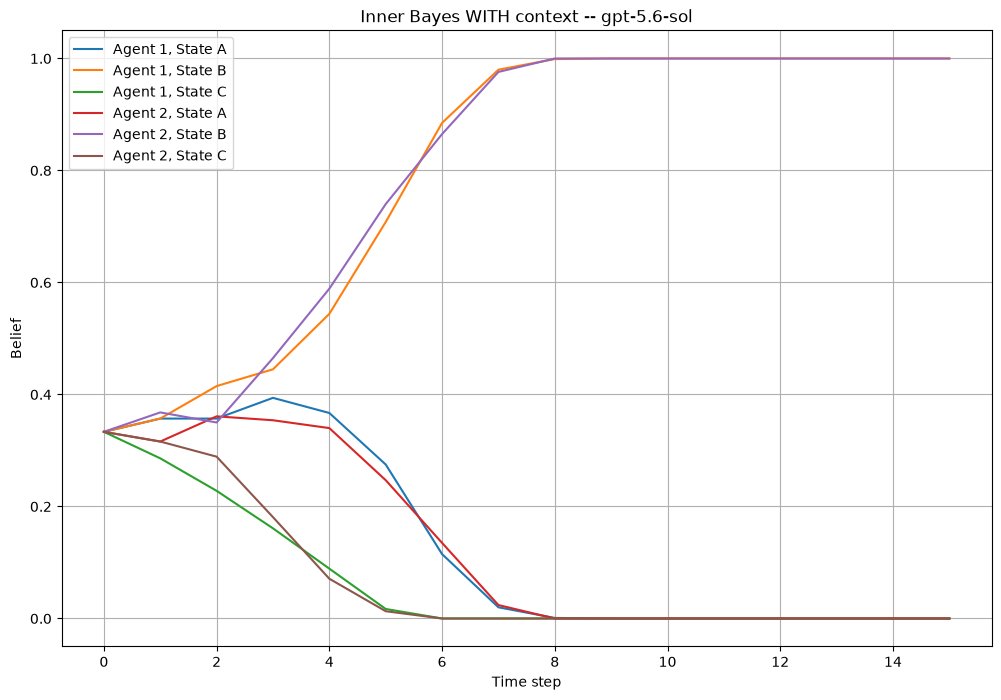

In [79]:
N_run = 15
Belief_init_1 = np.ones(K) / K
Belief_init_2 = np.ones(K) / K


Dyn_ctx = Dynamics_with_signal(
    Belief_init_1, Belief_init_2, Lx_close, Ly_close, N_run=15,
    context_prompt=CONTEXT_PROMPT)

plot_Dynamic(Dyn_ctx, title=f"Inner Bayes WITH context -- {MODEL_NAME}")

In [ ]:
import importlib
importlib.reload(LLMs_routines)
from LLMs_routines import *

print("="*70 + "\nWITHOUT CONTEXT\n" + "="*70)
res_no_ctx = test_homogeneity(n=10, label="[no context]")


WITHOUT CONTEXT
  [1/10] mu=[0.335 0.431 0.234]  zeta=[0.318 0.527 0.155]  slope=2.004
  [2/10] mu=[0.572 0.209 0.219]  zeta=[0.781 0.104 0.115]  slope=2.002
  [3/10] mu=[0.147 0.335 0.518]  zeta=[0.147 0.335 0.518]  slope=1.001
  [4/10] mu=[0.431 0.327 0.242]  zeta=[0.529 0.304 0.167]  slope=1.999
  [5/10] mu=[0.519 0.221 0.261]  zeta=[0.697 0.127 0.176]  slope=1.996
  [6/10] mu=[0.216 0.354 0.43 ]  zeta=[0.131 0.351 0.518]  slope=1.992
  [7/10] mu=[0.264 0.556 0.18 ]  zeta=[0.169 0.752 0.079]  slope=2.001
  [8/10] mu=[0.376 0.229 0.395]  zeta=[0.376 0.229 0.395]  slope=1.001
  [9/10] mu=[0.508 0.269 0.224]  zeta=[0.678 0.19  0.132]  slope=1.994
  [10/10] mu=[0.211 0.562 0.227]  zeta=[0.108 0.767 0.125]  slope=2.000

[no context]  rho_h = 1.799  (sd 0.399, n=10)  mean TV(zeta,mu) = 0.1242
  !! rho_h is not 1: kappa would NOT be identified under this condition


NameError: name 'res_ctx' is not defined

In [94]:
mu_test = np.array([0.335, 0.431, 0.234])

prompt = (
    f"Two independent assessors have each given a probability distribution "
    f"over the same {K} options. The labels are arbitrary and carry no "
    f"meaning.\n\nOptions: {', '.join(LABELS)}\n\n"
    f"Your own assessment:\n{fmt(mu_test, LABELS)}\n\n"
    f"The other assessor's assessment:\n{fmt(mu_test, LABELS)}\n\n"
    "No new evidence is available. Combining the two assessments, report "
    "your revised probability distribution as a JSON object mapping each "
    "label to a probability summing to 1, with three decimals. "
    "Output only the JSON object, nothing else."
)

print("="*70)
print("PROMPT SENT:")
print("="*70)
print(prompt)

response = client.responses.create(model=MODEL_NAME, input=prompt)

print("\n" + "="*70)
print("RAW RESPONSE:")
print("="*70)
print(repr(response.output_text))

print("\n" + "="*70)
print("PARSED:")
print("="*70)
match = re.search(r"\{.*\}", response.output_text, re.S)
if match:
    d = json.loads(match.group(0))
    print(d)
    z = np.array([float(d[L]) for L in LABELS])
    z = np.clip(z, 1e-6, None); z /= z.sum()
    print("normalized:", np.round(z, 4))
    print("\ninput mu       :", np.round(mu_test, 4))
    print("mu^2/sum(mu^2) :", np.round(mu_test**2 / np.sum(mu_test**2), 4))
else:
    print("no JSON found")

PROMPT SENT:
Two independent assessors have each given a probability distribution over the same 3 options. The labels are arbitrary and carry no meaning.

Options: A, B, C

Your own assessment:
A: 0.335
B: 0.431
C: 0.234

The other assessor's assessment:
A: 0.335
B: 0.431
C: 0.234

No new evidence is available. Combining the two assessments, report your revised probability distribution as a JSON object mapping each label to a probability summing to 1, with three decimals. Output only the JSON object, nothing else.

RAW RESPONSE:
'{"A":0.318,"B":0.527,"C":0.155}'

PARSED:
{'A': 0.318, 'B': 0.527, 'C': 0.155}
normalized: [0.318 0.527 0.155]

input mu       : [0.335 0.431 0.234]
mu^2/sum(mu^2) : [0.3182 0.5266 0.1552]
